In [ ]:
import models
import numpy as np
import matplotlib.pyplot as plt
import datavis as dv
from scipy.ndimage import gaussian_laplace as gl
from scipy.ndimage import gaussian_filter
from scipy.ndimage import gaussian_filter1d
import firstclassifierextras as fc

In [ ]:
# generate a dataset
T = 1000
datasize = 100
trials = 400
bw=20

# generate a random set of ramp parameters
beta = np.random.uniform(0, 4, datasize)
ln_sig = np.random.uniform(np.log(0.04), np.log(4), datasize)
ramp_params = np.column_stack((beta, np.exp(ln_sig)))

# generate a random set of step parameters
r = np.random.uniform(0.5, 6, datasize)
m = np.random.uniform(T/4, 3*T/4, datasize)
step_params = np.column_stack((m, r))

x_init = np.random.uniform(0, 0.5, datasize*2)


# generate simulations of each parameter set
ramp_dataset = np.array([models.RampModel(beta=ramp_params[i,0],
                                      sigma=ramp_params[i,1],
                                      x0 = x_init[i]).simulate(Ntrials=trials,
                                                               T=T)[0]
                                      for i in range(datasize)
                                      ]
                                    )
                                    
step_dataset = np.array([models.StepModel(m=step_params[j,0],
                                      r=step_params[j,1],
                                      x0 = x_init[j+datasize]).simulate(Ntrials=trials,
                                                                   T=T)[0]
                                      for j in range(datasize)
                                      ]
)

dataset = np.vstack((ramp_dataset, step_dataset))

In [ ]:
classifier, performance, disagreements = fc.fanoClassify(dataset, datasize)
print(performance)

0.7


In [ ]:
# classify based on maximum fano factor
mff = fc.genFanoClassifyMax(dataset, datasize)
print(fc.accuracy(mff, datasize)[0])

0.68


In [ ]:
# classify based on maximum derivative of fano factor
max_gs, mfd = fc.maxFanoDeriv(dataset, datasize, threshold=0.0005)
print(fc.accuracy(mfd, datasize)[0])

0.685


In [ ]:
rg, lgc = fc.rangeLoG(dataset, datasize)
print(fc.accuracy(lgc, datasize)[0])

0.73



=== Summary ===
max‑Fano    : accuracy =  68.0%  (136/200)
max‑dF/dt   : accuracy =  52.0%  (104/200)
LoG‑range   : accuracy =  73.0%  (146/200)
ensemble    : accuracy =  70.0%  (140/200)
Disagreements among the 3 votes: 124/200 samples
Indices with disagreement (first 20 shown): [ 0  3  4 10 13 14 17 20 21 22 25 31 34 36 37 39 40 43 45 48]


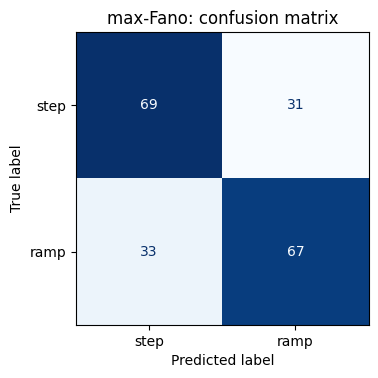

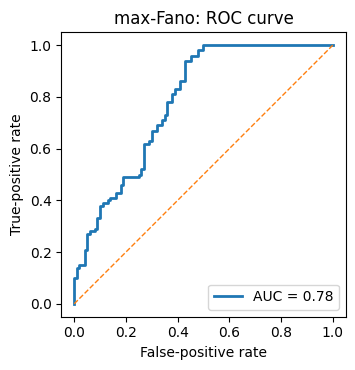

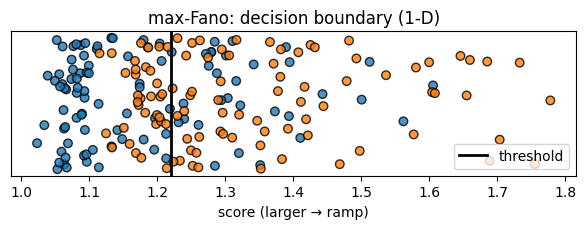

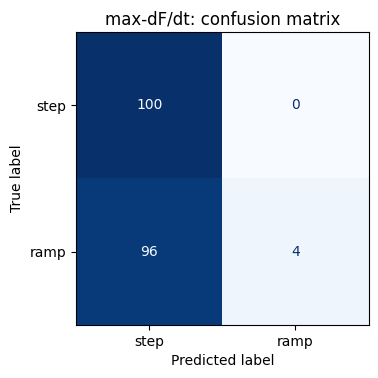

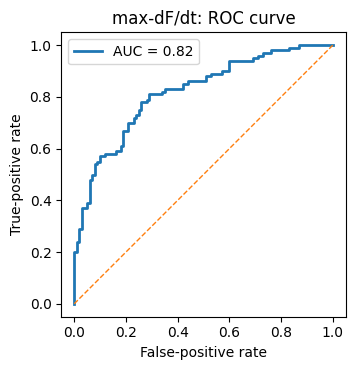

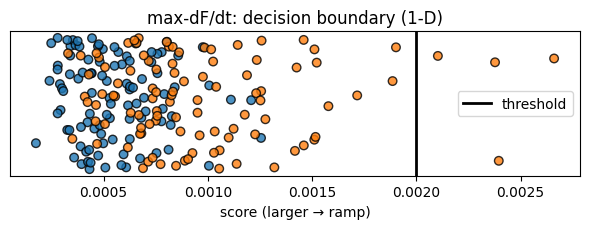

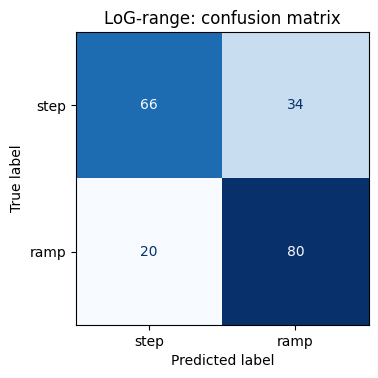

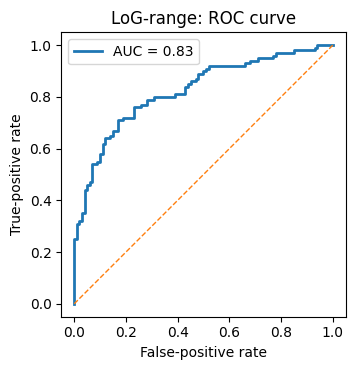

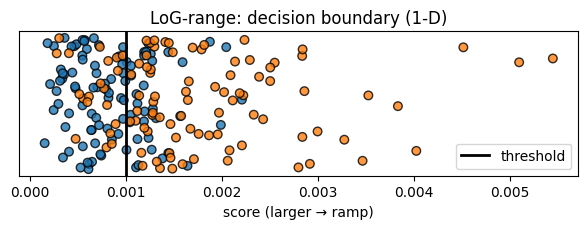

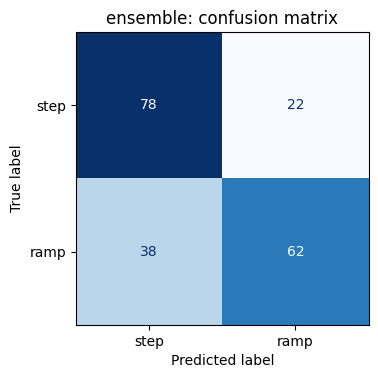

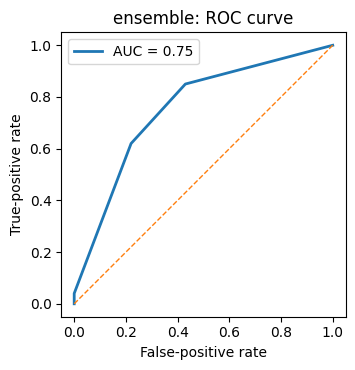

In [7]:
results = fc.evaluate_and_plot(dataset, datasize, T=T, bw=bw)

In [8]:

summary = fc.param_agreement_plot(
    ramp_params, step_params,
    results["mff_pred"], results["mfd_pred"], results["lgc_pred"],
    results["ensemble_pred"], y_true=np.array([0]*datasize + [1]*datasize)
)


/Users/lukagorchovbrearley/dev/gg3/gg3/firstclassifierextras.py:338: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker (np.str_('x')).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


NameError: name 'mlines' is not defined

Error in callback <function _draw_all_if_interactive at 0x114d0d820> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\\sigma$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\\sigma$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1000x450 with 2 Axes>